In [1]:
import h5py
# import jax
# jax.config.update("jax_enable_x64", True)
# from jax import numpy as jnp
# from jax import jit ,vmap
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
# from scipy.signal import convolve2d, fftconvolve # check jax
# from jax.scipy.signal import fftconvolve
# from jax.scipy.interpolate import RegularGridInterpolator
# from jax.scipy.ndimage import map_coordinates
import time

import os
import numpy
import numpy as np

from numpy.random import randint
import sklearn as sk
from sklearn.mixture import GaussianMixture # jaxxx??? # Hyakkk
from sklearn.decomposition import SparsePCA
from scipy.io import loadmat
import matplotlib as mpl
from matplotlib.colors import ListedColormap
# Seaborn colormap
import seaborn as sns
sns_list = sns.color_palette('deep').as_hex()
sns_list.insert(0, '#ffffff')  # Insert white at zero position
sns_cmap = ListedColormap(sns_list)
# import cv2
cm = sns_cmap
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, jaccard_score
from sklearn.metrics.cluster import normalized_mutual_info_score


mpl_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
            '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
            '#bcbd22', '#17becf']


In [6]:
#init PIV data load and phyyscial conversion
xx = np.load('PIV/GenDBTrialData/results/terms/xx.npy')
yy = np.load('PIV/GenDBTrialData/results/terms/yy.npy')
mask_weak = np.load('PIV/GenDBTrialData/mask_weak.npy')
mask_weak_bool = np.load('PIV/GenDBTrialData/mask_weak_bool.npy')
y_cutoff = 720

# Use the same waveamplitude scaling derived for the Weak WavyWall QuantComparison
scale = 0.2/239

PIV_x_physical = (xx-102)*scale +1.0
PIV_y_physical = (yy-21)*scale

cluster_idx_to_fill = np.load('PIV/post_sPCA_arrays/cluster_idx_to_fill_PIV.npy')[:y_cutoff,:]

In [7]:
# init DNS data load 
load_dir = 'DNS/results/'

nc = 12
trial = 0

cluster_idx_DNS = np.load(load_dir + f'nc{nc}/trial_{trial}/cluster_idx.npy')
masked_x_coords_DNS_grid = np.load(load_dir + f'nc{nc}/trial_{trial}/masked_x_coords_DNS_grid.npy')
masked_y_coords_DNS_grid = np.load(load_dir + f'nc{nc}/trial_{trial}/masked_y_coords_DNS_grid.npy')

balance_idx_DNS = np.load('DNS/post_sPCA_arrays/cluster_idx_to_fill_DNS.npy')

# Setup up interp grid for matching PIV & DNS

In [8]:
# truncate domain from [1.0,3.0] in physical space
PIV_x_left_trunc = np.argmin(np.abs(PIV_x_physical - 1.0))
PIV_x_right_trunc = np.argmin(np.abs(PIV_x_physical - 3.0))

PIV_x_physical_used = PIV_x_physical[PIV_x_left_trunc:PIV_x_right_trunc]

#truncate y according GMM cutoff since PIV y-domain is smaller than DNS:
PIV_y_physical_used = PIV_y_physical[:y_cutoff]

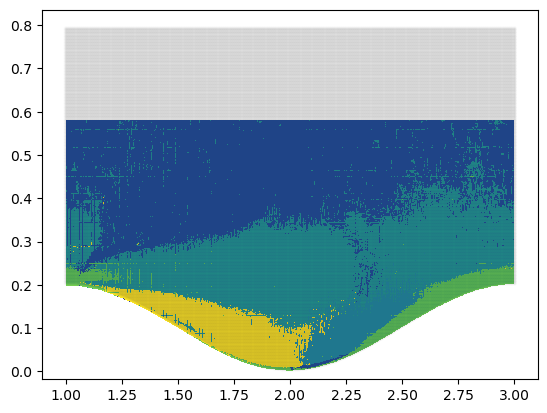

In [9]:
plt.pcolormesh(PIV_x_physical_used, PIV_y_physical_used, cluster_idx_to_fill[:,PIV_x_left_trunc:PIV_x_right_trunc]+1)
plt.scatter(masked_x_coords_DNS_grid, masked_y_coords_DNS_grid, s= 0.00001)


Looks above like we're good, slight errors on border won't really affect much

In [10]:
X_PIV_mesh, Y_PIV_mesh = np.meshgrid(PIV_x_physical_used, PIV_y_physical_used)

mask = ~np.isnan(cluster_idx_to_fill[:,PIV_x_left_trunc:PIV_x_right_trunc])

X_interp = X_PIV_mesh[mask]
Y_interp = Y_PIV_mesh[mask]

In [11]:
# Interp DNS clusters onto PIV
interp_DNS_labels = griddata(
                        np.array([masked_x_coords_DNS_grid, masked_y_coords_DNS_grid]).T,
                        balance_idx_DNS,
                        np.array([X_interp, Y_interp]).T,
                        method='nearest'
                    )

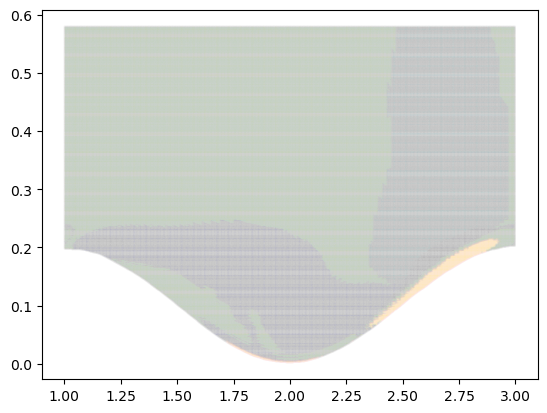

In [12]:
plt.scatter(X_interp, Y_interp, s= 0.00001, c=interp_DNS_labels)

Interp looks like it worked!

In [13]:
ari = adjusted_rand_score((cluster_idx_to_fill[:,PIV_x_left_trunc:PIV_x_right_trunc])[mask], interp_DNS_labels)
nmi = normalized_mutual_info_score((cluster_idx_to_fill[:,PIV_x_left_trunc:PIV_x_right_trunc])[mask], interp_DNS_labels)
ami = adjusted_mutual_info_score((cluster_idx_to_fill[:,PIV_x_left_trunc:PIV_x_right_trunc])[mask], interp_DNS_labels)

In [14]:
print(ari)
print(nmi)
print(ami)

0.22408503843907354
0.247761265557886
0.24775574196986155


# Much worse clustering alignment for Original DD-DB!!

In [14]:
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix

def hungarian_match_labels(y_true, y_pred):
    """
    Match cluster labels in y_pred to y_true using Hungarian assignment.

    Parameters
    ----------
    y_true : array-like
        Reference cluster labels.
    y_pred : array-like
        Cluster labels to permute.

    Returns
    -------
    y_pred_matched : ndarray
        Relabeled y_pred aligned to y_true.
    mapping : dict
        Mapping from original y_pred labels -> matched labels.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # Get all unique labels
    true_labels = np.unique(y_true)
    pred_labels = np.unique(y_pred)

    # Build overlap/confusion matrix
    cm = confusion_matrix(y_true, y_pred,
                          labels=true_labels)

    # Hungarian assignment (maximize overlap)
    row_ind, col_ind = linear_sum_assignment(-cm)

    # Build label mapping
    mapping = {
        pred_labels[c]: true_labels[r]
        for r, c in zip(row_ind, col_ind)
    }

    # Apply mapping
    y_pred_matched = np.array(
        [mapping.get(label, label) for label in y_pred]
    )

    return y_pred_matched, mapping
    

In [16]:
matched_DNS_labels, mapping = hungarian_match_labels(
    (cluster_idx_to_fill[:,PIV_x_left_trunc:PIV_x_right_trunc])[mask], 
    interp_DNS_labels
)

print(mapping)
# {2: 0, 0: 1, 1: 2}

print(matched_DNS_labels)
# [0 0 0 1 1 1 2 2 2]

{0.0: 0.0, 4.0: 1.0, 3.0: 2.0, 2.0: 3.0, 5.0: 4.0, 1.0: 5.0}
[4. 4. 4. ... 1. 1. 1.]


In [19]:
print(jaccard_score((cluster_idx_to_fill[:,PIV_x_left_trunc:PIV_x_right_trunc])[mask], 
               matched_DNS_labels,
               average='micro'))
print(jaccard_score((cluster_idx_to_fill[:,PIV_x_left_trunc:PIV_x_right_trunc])[mask], 
               matched_DNS_labels,
               average='macro'))
print(jaccard_score((cluster_idx_to_fill[:,PIV_x_left_trunc:PIV_x_right_trunc])[mask], 
               matched_DNS_labels,
               average='weighted'))

0.3695964164673671
0.21432505302337476
0.376287824681075
